# 08c) Colorado domain cloud fraction: ACM vs RGB vs TSI

Workflow:
- run the batch script to build an all-dates ACM/RGB cloud-fraction CSV for the fixed Colorado domain,
- merge that CSV with TSI cloud fraction for matching times,
- compare ACM and RGB cloud fraction against TSI, and
- inspect residuals plus a one-day diagnostic view.

Domain:
- latitude: `38.90` to `39.03`
- longitude: `-107.05` to `-106.92`
- notebook analysis window: `16Z` to `22Z`
- `BCM = 1` means cloud


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

DATE_SELECT = pd.Timestamp("2021-12-24")
TSI_MATCH_TOLERANCE = pd.Timedelta("3min")
START_HOUR_UTC = 16
END_HOUR_UTC = 22

LAT_BOUNDS = (38.90, 39.03)
LON_BOUNDS = (-107.05, -106.92)

GOES_CF_CSV = Path("/glade/u/home/cdalden/goes_work/analysis/output_08c/colorado_domain_cloud_fraction_14z_00z.csv")
TSI_PATH = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/sail_tsi_cloud_frac.csv")


In [14]:
def subset_latlon(ds, lat_bounds, lon_bounds, lat_name="latitude", lon_name="longitude"):
    lat_min, lat_max = sorted(lat_bounds)
    lon_min, lon_max = sorted(lon_bounds)
    lat_vals = ds[lat_name].values
    lon_vals = ds[lon_name].values
    lat_slice = slice(lat_max, lat_min) if lat_vals[0] > lat_vals[-1] else slice(lat_min, lat_max)
    lon_slice = slice(lon_max, lon_min) if lon_vals[0] > lon_vals[-1] else slice(lon_min, lon_max)
    return ds.sel({lat_name: lat_slice, lon_name: lon_slice})


def corr_or_nan(df, x, y):
    valid = df[[x, y]].dropna()
    if len(valid) < 2:
        return np.nan
    if valid[x].std(ddof=0) == 0 or valid[y].std(ddof=0) == 0:
        return np.nan
    return valid[x].corr(valid[y])


def mae(df, x, y):
    valid = df[[x, y]].dropna()
    if valid.empty:
        return np.nan
    return np.abs(valid[x] - valid[y]).mean()


def rmse(df, x, y):
    valid = df[[x, y]].dropna()
    if valid.empty:
        return np.nan
    return np.sqrt(np.mean((valid[x] - valid[y]) ** 2))


In [15]:
if not GOES_CF_CSV.exists():
    raise FileNotFoundError(
        f"Cloud-fraction CSV not found: {GOES_CF_CSV}\n"
        "Run: qsub /glade/u/home/cdalden/goes_work/analysis/submit_colorado_domain_cloud_fraction.pbs"
    )

goes_df = pd.read_csv(GOES_CF_CSV, parse_dates=["date", "t"])
tsi_df = pd.read_csv(TSI_PATH, parse_dates=["t"])

tsi_df.loc[tsi_df["tsi_frac"] < 0, "tsi_frac"] = np.nan
tsi_df = tsi_df.loc[(tsi_df["t"].dt.hour >= START_HOUR_UTC) & (tsi_df["t"].dt.hour < END_HOUR_UTC)].copy()
tsi_df = tsi_df.sort_values("t").reset_index(drop=True)

compare_df = pd.merge_asof(
    goes_df.sort_values("t"),
    tsi_df[["t", "tsi_frac"]].sort_values("t"),
    on="t",
    direction="nearest",
    tolerance=TSI_MATCH_TOLERANCE,
)

compare_df["acm_residual"] = compare_df["acm_cloud_frac"] - compare_df["tsi_frac"]
compare_df["rgb_residual"] = compare_df["rgb_cloud_frac"] - compare_df["tsi_frac"]

print("Rows in ACM/RGB CSV:", len(goes_df))
print("Rows with valid TSI match:", compare_df["tsi_frac"].notna().sum())
print("Available dates:", compare_df["date"].dt.strftime("%Y-%m-%d").nunique())

compare_df.head()


Rows in ACM/RGB CSV: 65280
Rows with valid TSI match: 37511
Available dates: 544


,date,date_key,t,acm_cloud_frac,rgb_cloud_frac,acm_n_pixels,rgb_n_pixels,acm_path,rgb_path,tsi_frac,acm_residual,rgb_residual
0,2021-10-01,20211001,2021-10-01 14:02:30,0.888889,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
1,2021-10-01,20211001,2021-10-01 14:07:30,0.833333,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
2,2021-10-01,20211001,2021-10-01 14:12:30,0.861111,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
3,2021-10-01,20211001,2021-10-01 14:17:30,0.916667,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
4,2021-10-01,20211001,2021-10-01 14:22:30,1.000000,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN


In [16]:
summary_df = pd.DataFrame(
    {
        "metric": [
            "Dates in CSV",
            "Rows in CSV",
            "Rows with valid TSI",
            "Mean ACM cloud fraction",
            "Mean RGB cloud fraction",
            "Mean TSI cloud fraction",
            "Corr(ACM, TSI)",
            "Corr(RGB, TSI)",
            "ACM mean residual",
            "RGB mean residual",
            "ACM MAE",
            "RGB MAE",
            "ACM RMSE",
            "RGB RMSE",
        ],
        "value": [
            compare_df["date"].dt.strftime("%Y-%m-%d").nunique(),
            len(compare_df),
            compare_df["tsi_frac"].notna().sum(),
            compare_df["acm_cloud_frac"].mean(),
            compare_df["rgb_cloud_frac"].mean(),
            compare_df["tsi_frac"].mean(),
            corr_or_nan(compare_df, "acm_cloud_frac", "tsi_frac"),
            corr_or_nan(compare_df, "rgb_cloud_frac", "tsi_frac"),
            compare_df["acm_residual"].mean(),
            compare_df["rgb_residual"].mean(),
            mae(compare_df, "acm_cloud_frac", "tsi_frac"),
            mae(compare_df, "rgb_cloud_frac", "tsi_frac"),
            rmse(compare_df, "acm_cloud_frac", "tsi_frac"),
            rmse(compare_df, "rgb_cloud_frac", "tsi_frac"),
        ],
    }
)

summary_df


,metric,value
0,Dates in CSV,544.000000
1,Rows in CSV,65280.000000
2,Rows with valid TSI,37511.000000
3,Mean ACM cloud fraction,0.558437
4,Mean RGB cloud fraction,0.419258
5,Mean TSI cloud fraction,0.428487
6,"Corr(ACM, TSI)",0.801143
7,"Corr(RGB, TSI)",0.812880
8,ACM mean residual,0.156222
9,RGB mean residual,0.082139


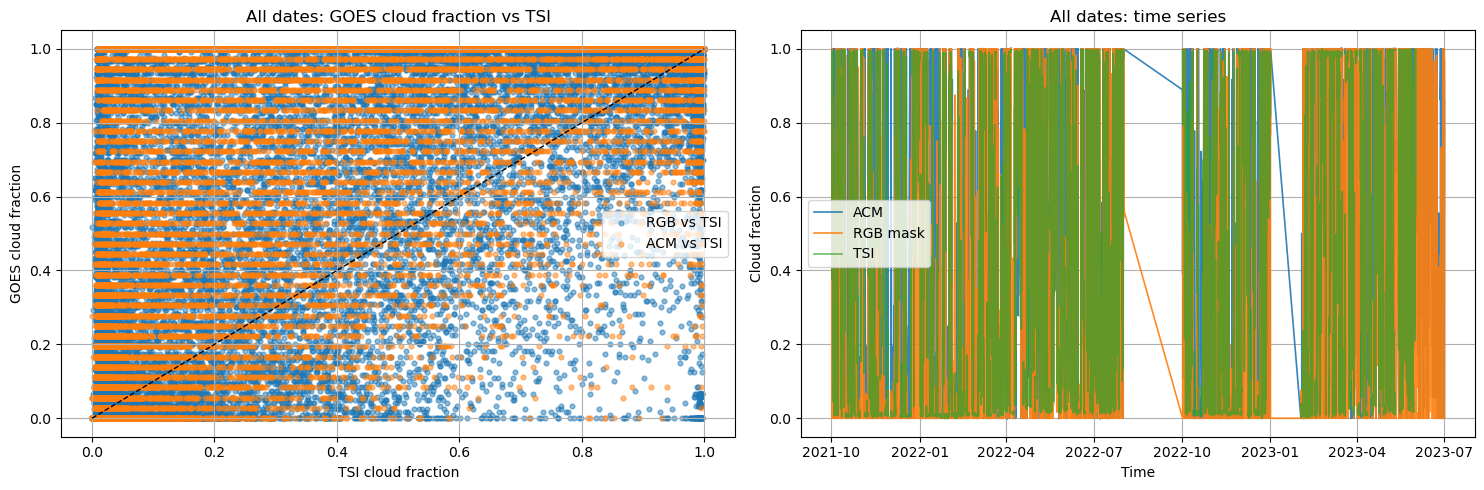

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

valid_rgb = compare_df[["tsi_frac", "rgb_cloud_frac"]].dropna()
valid_acm = compare_df[["tsi_frac", "acm_cloud_frac"]].dropna()

axes[0].scatter(valid_rgb["tsi_frac"], valid_rgb["rgb_cloud_frac"], s=12, alpha=0.5, label="RGB vs TSI")
axes[0].scatter(valid_acm["tsi_frac"], valid_acm["acm_cloud_frac"], s=12, alpha=0.5, label="ACM vs TSI")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("All dates: GOES cloud fraction vs TSI")
axes[0].set_xlabel("TSI cloud fraction")
axes[0].set_ylabel("GOES cloud fraction")
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

axes[1].plot(compare_df["t"], compare_df["acm_cloud_frac"], label="ACM", lw=1.2, alpha=0.9)
axes[1].plot(compare_df["t"], compare_df["rgb_cloud_frac"], label="RGB mask", lw=1.2, alpha=0.9)
axes[1].plot(compare_df["t"], compare_df["tsi_frac"], label="TSI", lw=1.2, alpha=0.7)
axes[1].set_title("All dates: time series")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Cloud fraction")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()


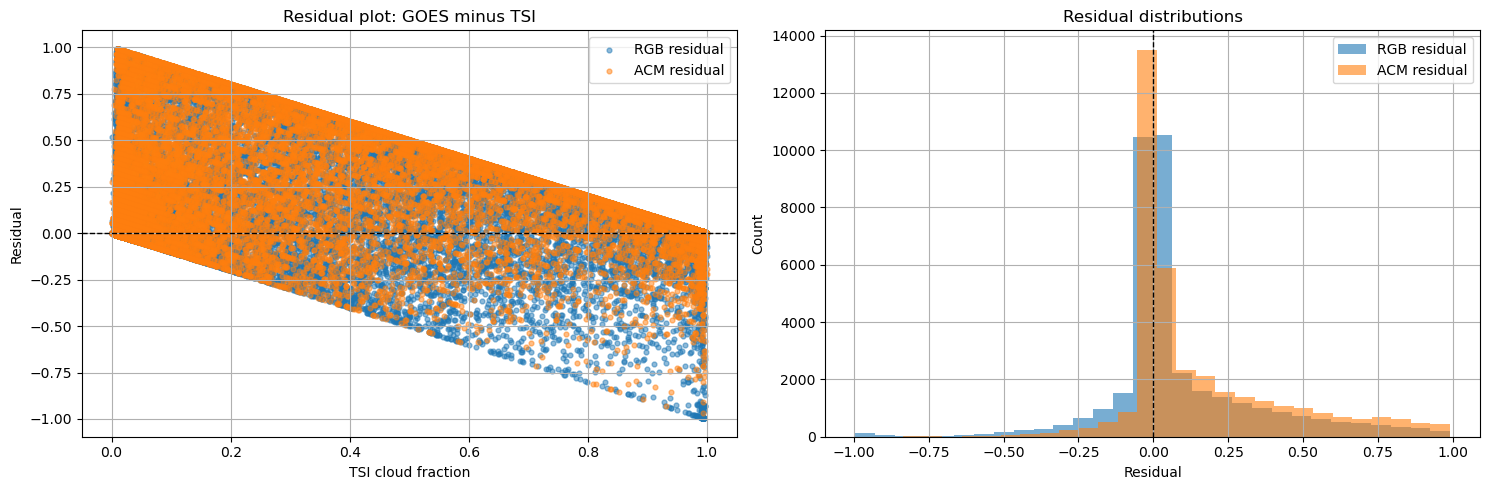

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

resid_rgb = compare_df[["tsi_frac", "rgb_residual"]].dropna()
resid_acm = compare_df[["tsi_frac", "acm_residual"]].dropna()

axes[0].scatter(resid_rgb["tsi_frac"], resid_rgb["rgb_residual"], s=12, alpha=0.5, label="RGB residual")
axes[0].scatter(resid_acm["tsi_frac"], resid_acm["acm_residual"], s=12, alpha=0.5, label="ACM residual")
axes[0].axhline(0, color="k", ls="--", lw=1)
axes[0].set_title("Residual plot: GOES minus TSI")
axes[0].set_xlabel("TSI cloud fraction")
axes[0].set_ylabel("Residual")
axes[0].legend()

axes[1].hist(resid_rgb["rgb_residual"], bins=30, alpha=0.6, label="RGB residual")
axes[1].hist(resid_acm["acm_residual"], bins=30, alpha=0.6, label="ACM residual")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_title("Residual distributions")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()


## Date Screening

Score each date separately with emphasis on mean residual bias so we can identify:
- dates where RGB is relatively unbiased but ACM has a large bias, and
- dates where both products have large mean residual bias.


In [19]:
date_metrics = []

for date_value, grp in compare_df.groupby(compare_df["date"].dt.normalize()):
    row = {
        "date": pd.Timestamp(date_value),
        "n_rows": len(grp),
        "n_valid_tsi": int(grp["tsi_frac"].notna().sum()),
        "acm_corr": corr_or_nan(grp, "acm_cloud_frac", "tsi_frac"),
        "rgb_corr": corr_or_nan(grp, "rgb_cloud_frac", "tsi_frac"),
        "acm_mae": mae(grp, "acm_cloud_frac", "tsi_frac"),
        "rgb_mae": mae(grp, "rgb_cloud_frac", "tsi_frac"),
        "acm_rmse": rmse(grp, "acm_cloud_frac", "tsi_frac"),
        "rgb_rmse": rmse(grp, "rgb_cloud_frac", "tsi_frac"),
        "acm_mean_residual": grp["acm_residual"].mean(),
        "rgb_mean_residual": grp["rgb_residual"].mean(),
    }
    row["acm_abs_mean_residual"] = np.abs(row["acm_mean_residual"])
    row["rgb_abs_mean_residual"] = np.abs(row["rgb_mean_residual"])
    row["rgb_minus_acm_abs_bias"] = row["acm_abs_mean_residual"] - row["rgb_abs_mean_residual"]
    row["joint_bias"] = np.nanmean([row["acm_abs_mean_residual"], row["rgb_abs_mean_residual"]])
    date_metrics.append(row)

date_metrics_df = pd.DataFrame(date_metrics).sort_values("date").reset_index(drop=True)
date_metrics_df


/glade/derecho/scratch/cdalden/tmp/ipykernel_33217/4126951539.py:20: RuntimeWarning: Mean of empty slice
  row["joint_bias"] = np.nanmean([row["acm_abs_mean_residual"], row["rgb_abs_mean_residual"]])
/glade/derecho/scratch/cdalden/tmp/ipykernel_33217/4126951539.py:20: RuntimeWarning: Mean of empty slice
  row["joint_bias"] = np.nanmean([row["acm_abs_mean_residual"], row["rgb_abs_mean_residual"]])
/glade/derecho/scratch/cdalden/tmp/ipykernel_33217/4126951539.py:20: RuntimeWarning: Mean of empty slice
  row["joint_bias"] = np.nanmean([row["acm_abs_mean_residual"], row["rgb_abs_mean_residual"]])
/glade/derecho/scratch/cdalden/tmp/ipykernel_33217/4126951539.py:20: RuntimeWarning: Mean of empty slice
  row["joint_bias"] = np.nanmean([row["acm_abs_mean_residual"], row["rgb_abs_mean_residual"]])
/glade/derecho/scratch/cdalden/tmp/ipykernel_33217/4126951539.py:20: RuntimeWarning: Mean of empty slice
  row["joint_bias"] = np.nanmean([row["acm_abs_mean_residual"], row["rgb_abs_mean_residual"]])


,date,n_rows,n_valid_tsi,acm_corr,rgb_corr,acm_mae,rgb_mae,acm_rmse,rgb_rmse,acm_mean_residual,rgb_mean_residual,acm_abs_mean_residual,rgb_abs_mean_residual,rgb_minus_acm_abs_bias,joint_bias
0,2021-10-01,120,73,NaN,0.381858,0.158223,0.137222,0.236691,0.192789,0.158223,0.049890,0.158223,0.049890,0.108333,0.104057
1,2021-10-02,120,74,0.566689,0.545697,0.360358,0.240669,0.436156,0.333107,0.360358,-0.210175,0.360358,0.210175,0.150182,0.285267
2,2021-10-03,120,74,0.806251,0.720227,0.302283,0.152566,0.354858,0.191602,0.300287,-0.117881,0.300287,0.117881,0.182406,0.209084
3,2021-10-04,120,74,0.723421,0.602189,0.059901,0.062933,0.084789,0.091266,0.003385,-0.045339,0.003385,0.045339,-0.041954,0.024362
4,2021-10-05,120,74,0.924976,0.835168,0.173115,0.171530,0.225585,0.238117,0.168878,-0.113066,0.168878,0.113066,0.055812,0.140972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,2023-06-26,120,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,2023-06-27,120,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541,2023-06-28,120,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
542,2023-06-29,120,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
MIN_VALID_TSI_ROWS = 12
RGB_GOOD_ABS_MEAN_RESIDUAL_MAX = 0.10
ACM_BAD_ABS_MEAN_RESIDUAL_MIN = 0.25
BOTH_BAD_ABS_MEAN_RESIDUAL_MIN = 0.20

rgb_good_acm_bad_df = (
    date_metrics_df.loc[
        (date_metrics_df["n_valid_tsi"] >= MIN_VALID_TSI_ROWS)
        & (date_metrics_df["rgb_abs_mean_residual"] <= RGB_GOOD_ABS_MEAN_RESIDUAL_MAX)
        & (date_metrics_df["acm_abs_mean_residual"] >= ACM_BAD_ABS_MEAN_RESIDUAL_MIN)
    ]
    .sort_values(["rgb_abs_mean_residual", "acm_abs_mean_residual"], ascending=[True, False])
    .reset_index(drop=True)
)

both_bad_df = (
    date_metrics_df.loc[
        (date_metrics_df["n_valid_tsi"] >= MIN_VALID_TSI_ROWS)
        & (date_metrics_df["rgb_abs_mean_residual"] >= BOTH_BAD_ABS_MEAN_RESIDUAL_MIN)
        & (date_metrics_df["acm_abs_mean_residual"] >= BOTH_BAD_ABS_MEAN_RESIDUAL_MIN)
    ]
    .sort_values(["joint_bias", "acm_abs_mean_residual", "rgb_abs_mean_residual"], ascending=[False, False, False])
    .reset_index(drop=True)
)

print("Dates where RGB is relatively unbiased but ACM is strongly biased:", len(rgb_good_acm_bad_df))
rgb_good_acm_bad_df[
    ["date", "n_valid_tsi", "rgb_mean_residual", "acm_mean_residual", "rgb_abs_mean_residual", "acm_abs_mean_residual", "rgb_corr", "acm_corr"]
].head(15)

print("Dates where both ACM and RGB are strongly biased:", len(both_bad_df))
both_bad_df[
    ["date", "n_valid_tsi", "rgb_mean_residual", "acm_mean_residual", "rgb_abs_mean_residual", "acm_abs_mean_residual", "rgb_corr", "acm_corr"]
].head(15)


Dates where RGB is relatively unbiased but ACM is strongly biased: 64
Dates where both ACM and RGB are strongly biased: 50


,date,n_valid_tsi,rgb_mean_residual,acm_mean_residual,rgb_abs_mean_residual,acm_abs_mean_residual,rgb_corr,acm_corr
0,2022-03-17,74,0.695574,0.515657,0.695574,0.515657,-0.061338,0.133531
1,2023-04-05,68,0.658159,0.548600,0.658159,0.548600,0.278487,0.271778
2,2023-03-16,74,0.736332,0.456302,0.736332,0.456302,0.585970,0.586797
3,2022-03-22,74,0.795364,0.315973,0.795364,0.315973,0.402463,0.519668
4,2023-03-24,74,0.533118,0.546293,0.533118,0.546293,-0.118544,0.162106
5,2022-01-01,74,0.493619,0.564040,0.493619,0.564040,0.248285,0.579232
6,2022-04-24,74,0.567788,0.469703,0.567788,0.469703,0.239043,0.590250
7,2022-03-03,74,0.277024,0.753938,0.277024,0.753938,-0.141286,0.255123
8,2022-03-18,74,0.478375,0.545205,0.478375,0.545205,0.622241,0.582206
9,2022-03-21,74,0.727307,0.274904,0.727307,0.274904,0.406189,0.694352


,date,date_key,t,acm_cloud_frac,rgb_cloud_frac,acm_n_pixels,rgb_n_pixels,acm_path,rgb_path,tsi_frac,acm_residual,rgb_residual
0,2021-12-24,20211224,2021-12-24 14:02:30,1.0,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
1,2021-12-24,20211224,2021-12-24 14:07:30,1.0,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
2,2021-12-24,20211224,2021-12-24 14:12:30,1.0,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
3,2021-12-24,20211224,2021-12-24 14:17:30,1.0,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN
4,2021-12-24,20211224,2021-12-24 14:22:30,1.0,0.0,36,120,/glade/u/home/cdalden/scratch/colorado_acm/goe...,/glade/u/home/cdalden/scratch/colorado_rgbmask...,NaN,NaN,NaN


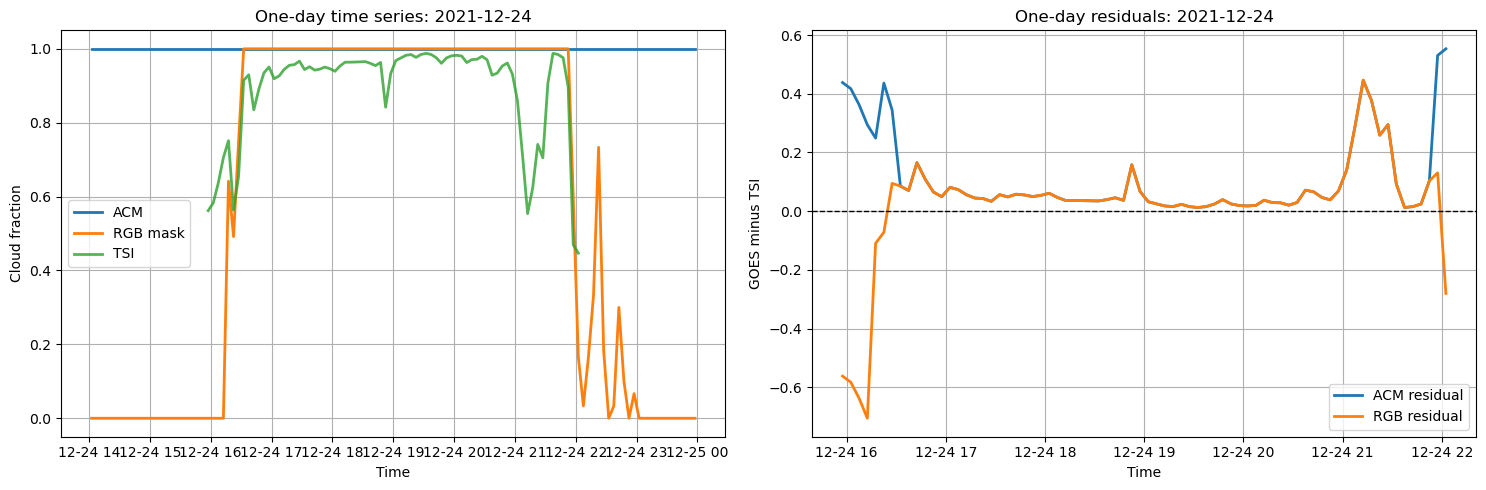

In [21]:
day_df = compare_df.loc[compare_df["date"].dt.normalize() == DATE_SELECT.normalize()].copy()
day_df = day_df.sort_values("t").reset_index(drop=True)

if day_df.empty:
    raise ValueError(f"No rows found for {DATE_SELECT.date()}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(day_df["t"], day_df["acm_cloud_frac"], label="ACM", lw=2)
axes[0].plot(day_df["t"], day_df["rgb_cloud_frac"], label="RGB mask", lw=2)
axes[0].plot(day_df["t"], day_df["tsi_frac"], label="TSI", lw=2, alpha=0.8)
axes[0].set_title(f"One-day time series: {DATE_SELECT.date()}")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Cloud fraction")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

axes[1].plot(day_df["t"], day_df["acm_residual"], label="ACM residual", lw=2)
axes[1].plot(day_df["t"], day_df["rgb_residual"], label="RGB residual", lw=2)
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_title(f"One-day residuals: {DATE_SELECT.date()}")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("GOES minus TSI")
axes[1].legend()

plt.tight_layout()

day_df.head()


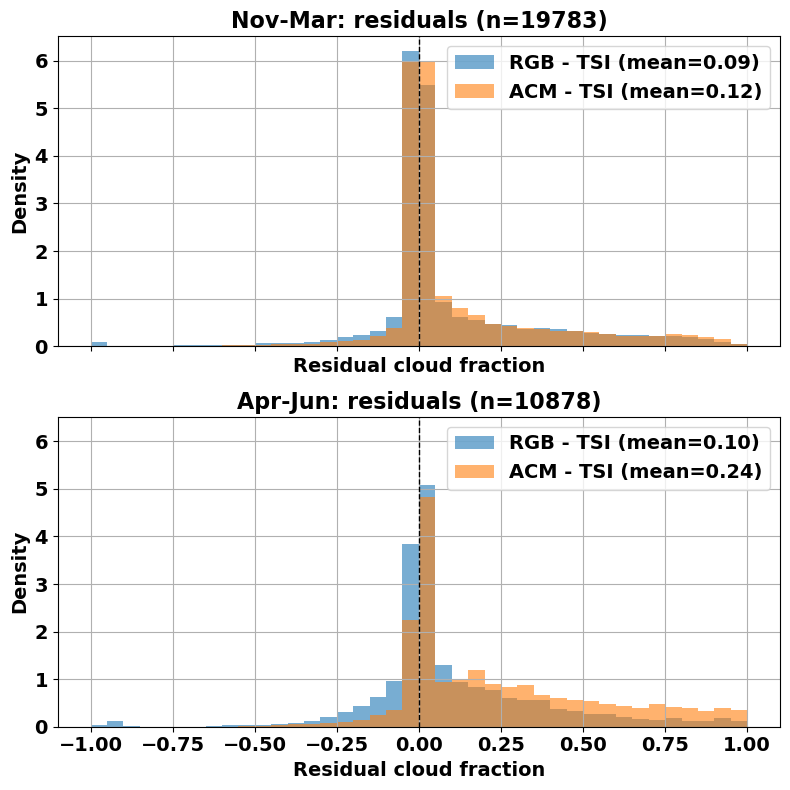

In [22]:
period_defs = [
    ("Nov-Mar", [11, 12, 1, 2, 3]),
    ("Apr-Jun", [4, 5, 6]),
    # ("Jul-Oct", [7, 8, 9, 10]),
]

hist_df = compare_df.loc[compare_df["tsi_frac"].notna()].copy()
hist_df["rgb_minus_tsi_residual"] = hist_df["rgb_cloud_frac"] - hist_df["tsi_frac"]
hist_df["acm_minus_tsi_residual"] = hist_df["acm_cloud_frac"] - hist_df["tsi_frac"]

bins = np.linspace(-1, 1, 41)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)

for ax, (period_label, months) in zip(axes, period_defs):
    period_df = hist_df.loc[hist_df["t"].dt.month.isin(months)]
    rgb_tsi = period_df["rgb_minus_tsi_residual"].dropna()
    acm_tsi = period_df["acm_minus_tsi_residual"].dropna()

    ax.hist(rgb_tsi, bins=bins, alpha=0.6, density=True, label=f"RGB - TSI (mean={rgb_tsi.mean():.2f})")
    ax.hist(acm_tsi, bins=bins, alpha=0.6, density=True, label=f"ACM - TSI (mean={acm_tsi.mean():.2f})")
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_title(f"{period_label}: residuals (n={len(period_df)})", fontweight="bold", fontsize=16)
    ax.set_xlabel("Residual cloud fraction", fontweight="bold", fontsize=14)
    ax.set_ylabel("Density", fontweight="bold", fontsize=14)
    ax.legend(prop={"weight": "bold", "size": 14})
    ax.tick_params(axis='both', which='major', labelsize=14)

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

plt.tight_layout()

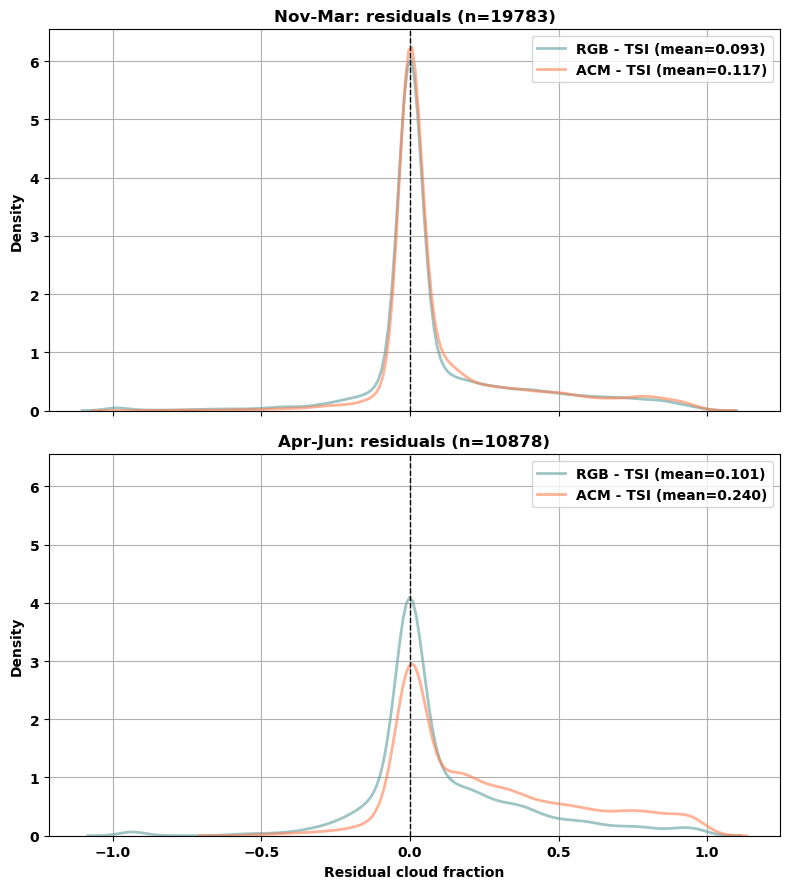

In [23]:
import seaborn as sns

period_defs = [
    ("Nov-Mar", [11, 12, 1, 2, 3]),
    ("Apr-Jun", [4, 5, 6]),
    # ("Jul-Oct", [7, 8, 9, 10]),
]

hist_df = compare_df.loc[compare_df["tsi_frac"].notna()].copy()
hist_df["rgb_minus_tsi_residual"] = hist_df["rgb_cloud_frac"] - hist_df["tsi_frac"]
hist_df["acm_minus_tsi_residual"] = hist_df["acm_cloud_frac"] - hist_df["tsi_frac"]

fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True, sharey=True)

for ax, (period_label, months) in zip(axes, period_defs):
    period_df = hist_df.loc[hist_df["t"].dt.month.isin(months)]
    rgb_tsi = period_df["rgb_minus_tsi_residual"].dropna()
    acm_tsi = period_df["acm_minus_tsi_residual"].dropna()

    # KDE plots
    sns.kdeplot(data=rgb_tsi, ax=ax, alpha=0.6, linewidth=2, 
                label=f"RGB - TSI (mean={rgb_tsi.mean():.3f})", color='cadetblue')
    sns.kdeplot(data=acm_tsi, ax=ax, alpha=0.6, linewidth=2, 
                label=f"ACM - TSI (mean={acm_tsi.mean():.3f})", color='coral')
    
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_title(f"{period_label}: residuals (n={len(period_df)})", fontweight="bold")
    ax.set_xlabel("Residual cloud fraction", fontweight="bold")
    ax.set_ylabel("Density", fontweight="bold")
    ax.legend(prop={"weight": "bold"})

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

plt.tight_layout()

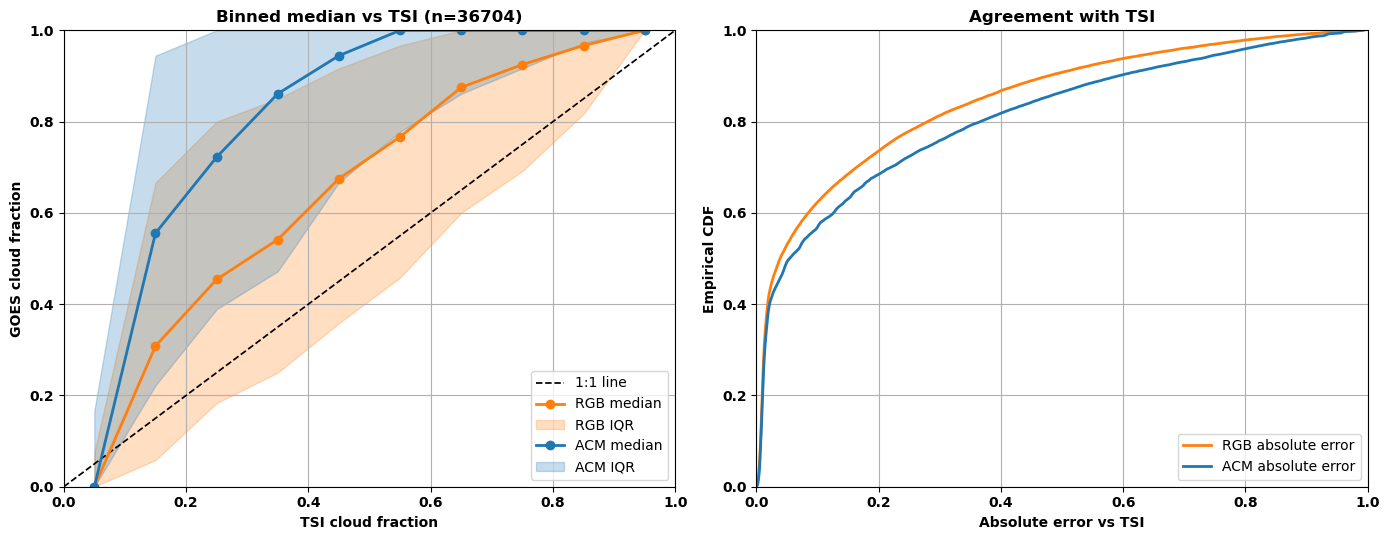

In [26]:
plot_df = compare_df.loc[
    compare_df[["tsi_frac", "rgb_cloud_frac", "acm_cloud_frac"]].notna().all(axis=1)
].copy()
plot_df["rgb_abs_error"] = np.abs(plot_df["rgb_cloud_frac"] - plot_df["tsi_frac"])
plot_df["acm_abs_error"] = np.abs(plot_df["acm_cloud_frac"] - plot_df["tsi_frac"])

bin_edges = np.linspace(0, 1, 11)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plot_df["tsi_bin"] = pd.cut(plot_df["tsi_frac"], bins=bin_edges, include_lowest=True)

def binned_summary(df, value_col):
    grouped = df.groupby("tsi_bin", observed=False)[value_col]
    return pd.DataFrame({
        "median": grouped.median(),
        "q25": grouped.quantile(0.25),
        "q75": grouped.quantile(0.75),
        "count": grouped.count(),
    })

rgb_summary = binned_summary(plot_df, "rgb_cloud_frac")
acm_summary = binned_summary(plot_df, "acm_cloud_frac")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot([0, 1], [0, 1], color="k", ls="--", lw=1.25, label="1:1 line")
ax.plot(bin_centers, rgb_summary["median"], color="tab:orange", lw=2, marker="o", label="RGB median")
ax.fill_between(bin_centers, rgb_summary["q25"], rgb_summary["q75"], color="tab:orange", alpha=0.25, label="RGB IQR")
ax.plot(bin_centers, acm_summary["median"], color="tab:blue", lw=2, marker="o", label="ACM median")
ax.fill_between(bin_centers, acm_summary["q25"], acm_summary["q75"], color="tab:blue", alpha=0.25, label="ACM IQR")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("TSI cloud fraction", fontweight="bold")
ax.set_ylabel("GOES cloud fraction", fontweight="bold")
ax.set_title(f"Binned median vs TSI (n={len(plot_df)})", fontweight="bold")
ax.legend(frameon=True)

ax = axes[1]
for err_col, label, color in [
    ("rgb_abs_error", "RGB absolute error", "tab:orange"),
    ("acm_abs_error", "ACM absolute error", "tab:blue"),
]:
    vals = np.sort(plot_df[err_col].dropna().to_numpy())
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf, lw=2, color=color, label=label)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Absolute error vs TSI", fontweight="bold")
ax.set_ylabel("Empirical CDF", fontweight="bold")
ax.set_title("Agreement with TSI", fontweight="bold")
ax.legend(frameon=True, loc="lower right")

for ax in axes:
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

plt.tight_layout()